<a href="https://colab.research.google.com/github/TerteryanTatev/Optimization-Methods/blob/main/Golden_Section_Search.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import math
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate


In [ ]:
#Function Definition

def define_function():
    x = sp.symbols('x')
    f_sym = x**2 - 4 * sp.sin(x)
    f_num = sp.lambdify(x, f_sym, "numpy")
    return x, f_sym, f_num


In [ ]:
#Analytical Solution
def analytical_extrema(x, f_sym, guess=1.0):
    derivative = sp.diff(f_sym, x)
    root = sp.nsolve(derivative, x, guess)
    return float(root)



In [ ]:

#Golden Section (fixed n)
def golden_section(f, a, b, ep=0.1):
    import math

    r = (math.sqrt(5) - 1) / 2
    steps = []
    i = 1
    while abs(b - a) > ep:

        x1 = b - r * (b - a)
        x2 = a + r * (b - a)

        f1 = f(x1)
        f2 = f(x2)

        a_old, b_old = a, b

        if f1 < f2:
            b = x2
        else:
            a = x1

        steps.append([
            i,
            a_old, b_old,
            x1, x2,
            f1, f2,
            a, b
        ])
        i+=1
    xmin = (a + b) / 2
    ymin = f(xmin)

    return xmin, ymin, steps

In [ ]:

#Table Output
def print_table(steps):
    headers = [
        "Step",
        "a_old", "b_old",
        "x1", "x2",
        "f(x1)", "f(x2)",
        "a_new", "b_new"
    ]
    print(tabulate(steps, headers=headers, floatfmt=".5f"), '\n')

In [ ]:

#Plotting
def plot_iterations(f, steps, xmin=None, ymin=None, x_analytical=None, y_analytical=None):
    for step in steps:
        i,  a, b, x1, x2, f1, f2, a_new, b_new, = step

        X = np.linspace(a - 0.5, b + 0.5, 500)
        Y = f(X)

        plt.figure(figsize=(9, 6))

        plt.plot(X, Y, linewidth=2)

        plt.axvline(a, linestyle="--", linewidth=1.5)
        plt.axvline(b, linestyle="--", linewidth=1.5)

        plt.scatter(x1, f1, s=120, marker='o', edgecolors='black', zorder=3, label="x1")
        plt.scatter(x2, f2, s=120, marker='s', edgecolors='black', zorder=3, label="x2")

        offset_y = (max(Y) - min(Y)) * 0.08
        offset_x = (b - a) * 0.05

        if x1 < x2:
            x1_text = (x1 - offset_x, f1 + offset_y)
            x2_text = (x2 + offset_x, f2 + offset_y)
        else:
            x1_text = (x1 + offset_x, f1 + offset_y)
            x2_text = (x2 - offset_x, f2 + offset_y)

        plt.annotate(f"x1={x1:.2f}",
                     xy=(x1, f1),
                     xytext=x1_text,
                     arrowprops=dict(arrowstyle="->", lw=1.5))

        plt.annotate(f"x2={x2:.2f}",
                     xy=(x2, f2),
                     xytext=x2_text,
                     arrowprops=dict(arrowstyle="->", lw=1.5))

        if xmin is not None and i == steps[-1][0]:
            plt.scatter(xmin, ymin, s=180, marker='*', edgecolors='black', zorder=4, label="Golden Min")

            plt.annotate(f"min≈{xmin:.3f}",
                         xy=(xmin, ymin),
                         xytext=(xmin, ymin + 2 * offset_y),
                         arrowprops=dict(arrowstyle="->", lw=1.5))

        if x_analytical is not None:
            plt.scatter(x_analytical, y_analytical, s=140, marker='X', edgecolors='black', zorder=4, label="Analytical Min")

            plt.annotate(f"analyt≈{x_analytical:.3f}",
                         xy=(x_analytical, y_analytical),
                         xytext=(x_analytical, y_analytical - 2 * offset_y),
                         arrowprops=dict(arrowstyle="->", lw=1.5))

        plt.title(f"Iteration {i}")
        plt.xlabel("x")
        plt.ylabel("f(x)")
        plt.grid(True)
        plt.legend()

        plt.show()

In [ ]:

def main():

    x, f_sym, f_num = define_function()

    x_analytical = analytical_extrema(x, f_sym, guess=1)
    y_analytical = f_num(x_analytical)
    print("Analytical minimum:")
    print(f"x = {x_analytical:.5f}")
    print(f"f(x) = {f_num(x_analytical):.5f} \n")

    a, b = 0.5, 3
    ep = 0.5

    xmin, ymin, steps = golden_section(f_num, a, b, ep)


    print_table(steps)

    print("\nFinal result:")
    print(f"x_min = {xmin:.5f}")
    print(f"f(x_min) = {ymin:.5f}")

    plot_iterations(
    f_num,
    steps,
    xmin=xmin,
    ymin=ymin,
    x_analytical=x_analytical,
    y_analytical=y_analytical
    )

Analytical minimum:
x = 1.02987
f(x) = -2.36830 

  Step    a_old    b_old       x1       x2     f(x1)     f(x2)    a_new    b_new
------  -------  -------  -------  -------  --------  --------  -------  -------
     1  0.50000  3.00000  1.45492  2.04508  -1.85640   0.62390  0.50000  2.04508
     2  0.50000  2.04508  1.09017  1.45492  -2.35835  -1.85640  0.50000  1.45492
     3  0.50000  1.45492  0.86475  1.09017  -2.29594  -2.35835  0.86475  1.45492
     4  0.86475  1.45492  1.09017  1.22949  -2.35835  -2.25763  0.86475  1.22949 


Final result:
x_min = 1.04712
f(x_min) = -2.36749


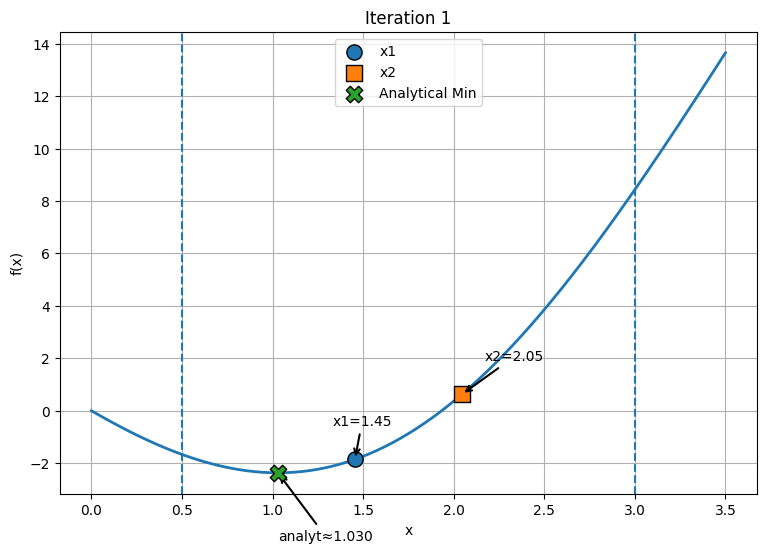

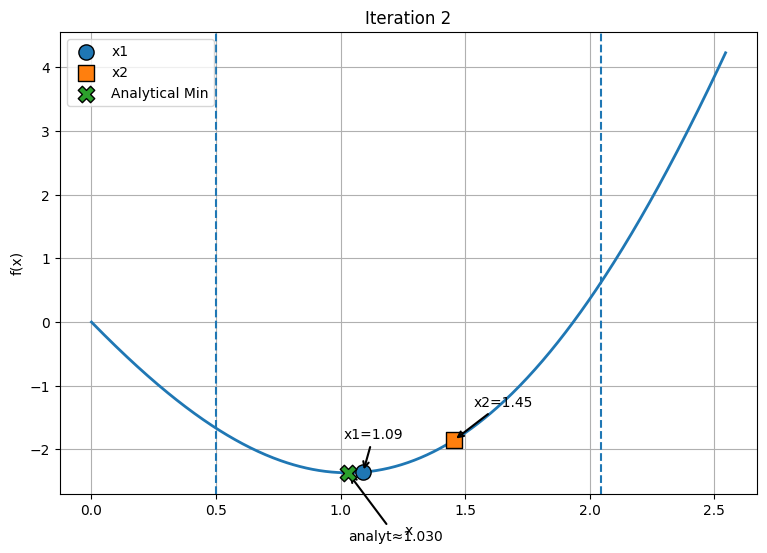

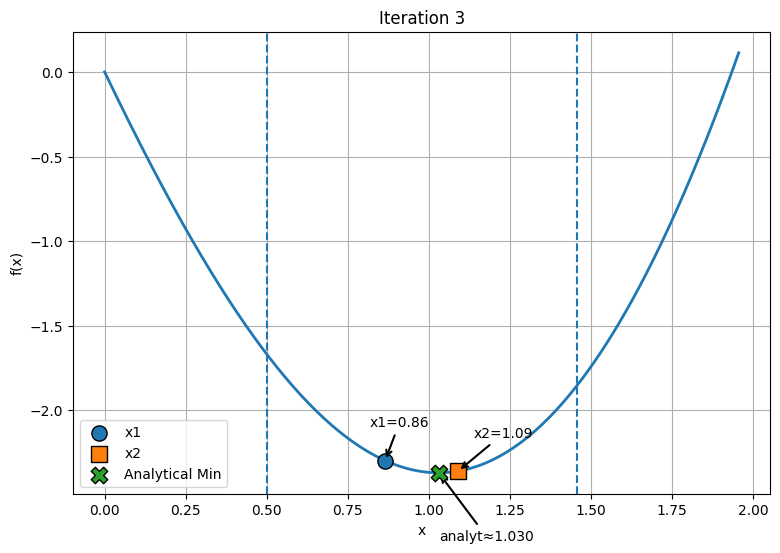

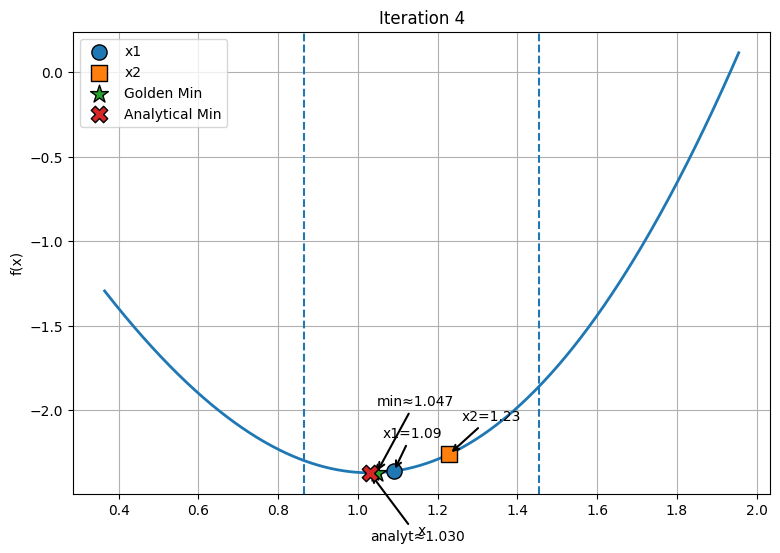

In [ ]:
if __name__ == "__main__":
  main()